In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import trim_mean
from scipy.stats import median_abs_deviation
from scipy.stats import skew
from scipy.stats import probplot

%matplotlib inline

In [ ]:
from sklearn.datasets import load_iris

# Load the Iris dataset from sklearn
iris = load_iris()

df = pd.DataFrame(data=np.c_[iris['data'], iris['target']],
                  columns=iris['feature_names'] + ['target'])

# Map target integers to species names
species_map = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
df['target'] = df['target'].map(species_map)

# Rename columns to match the original structure, if desired
df = df.rename(columns={
    'sepal length (cm)': 'SepalLength',
    'sepal width (cm)': 'SepalWidth',
    'petal length (cm)': 'PetalLength',
    'petal width (cm)': 'PetalWidth',
    'target': 'Species'
})

print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
rows, cols = df.shape

print("Shape of Dataset:")
print(df.shape)

print("\nObservation:")
print(f"The dataset contains {rows} rows and {cols} columns.")

Shape of Dataset:
(150, 5)

Observation:
The dataset contains 150 rows and 5 columns.


In [ ]:
df.info()

print("\nObservation:")

numeric = len(df.select_dtypes(include=['number']).columns)
categorical = len(df.select_dtypes(include=['object']).columns)

print(f"The dataset has {numeric} numerical columns.")
print(f"The dataset has {categorical} categorical column.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   SepalLength  150 non-null    float64
 1   SepalWidth   150 non-null    float64
 2   PetalLength  150 non-null    float64
 3   PetalWidth   150 non-null    float64
 4   Species      150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Observation:
The dataset has 4 numerical columns.
The dataset has 1 categorical column.


In [ ]:
print("First Five Records")
display(df.head())

print("\nLast Five Records")
display(df.tail())

print("\nObservation:")
print("The first and last records were displayed successfully.")

First Five Records


,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Last Five Records


,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica



Observation:
The first and last records were displayed successfully.


In [ ]:
missing = df.isnull().sum()

print(missing)

print("\nObservation:")

if missing.sum()==0:
    print("No missing values are present in the dataset.")
else:
    print(f"Total Missing Values = {missing.sum()}")

SepalLength    0
SepalWidth     0
PetalLength    0
PetalWidth     0
Species        0
dtype: int64

Observation:
No missing values are present in the dataset.


In [ ]:
summary = df.describe()

display(summary)

print("\nObservation:")

print(f"Average Sepal Length = {summary.loc['mean','SepalLength']:.2f}")
print(f"Average Petal Length = {summary.loc['mean','PetalLength']:.2f}")

,SepalLength,SepalWidth,PetalLength,PetalWidth
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



Observation:
Average Sepal Length = 5.84
Average Petal Length = 3.76


In [ ]:
species = df["Species"].value_counts()

print(species)

print("\nObservation:")

print(f"Number of Species = {len(species)}")

for flower,count in species.items():
    print(f"{flower} contains {count} samples.")

Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Observation:
Number of Species = 3
setosa contains 50 samples.
versicolor contains 50 samples.
virginica contains 50 samples.


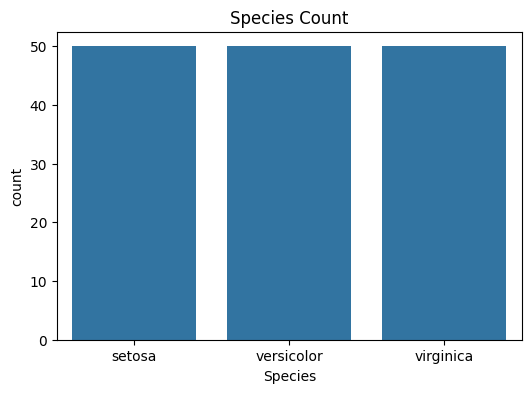


Observation:
The highest number of samples belongs to setosa.
All species have equal number of samples.


In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x="Species",data=df)

plt.title("Species Count")

plt.show()

print("\nObservation:")

largest = species.idxmax()

print(f"The highest number of samples belongs to {largest}.")

if species.nunique()==1:
    print("All species have equal number of samples.")

In [ ]:
numeric = df.select_dtypes(include=np.number)

print("MEAN\n")
print(numeric.mean())

print("\nMEDIAN\n")
print(numeric.median())

print("\nTRIMMED MEAN\n")

for col in numeric.columns:
    print(col,":",trim_mean(numeric[col],0.1))

print("\nWEIGHTED MEAN\n")

weights=np.arange(1,len(df)+1)

for col in numeric.columns:
    wm=np.average(numeric[col],weights=weights)
    print(col,":",wm)

print("\nObservation:")

highest=numeric.mean().idxmax()

print(f"The feature having highest average value is {highest}.")

MEAN

SepalLength    5.843333
SepalWidth     3.057333
PetalLength    3.758000
PetalWidth     1.199333
dtype: float64

MEDIAN

SepalLength    5.80
SepalWidth     3.00
PetalLength    4.35
PetalWidth     1.30
dtype: float64

TRIMMED MEAN

SepalLength : 5.8083333333333345
SepalWidth : 3.0433333333333334
PetalLength : 3.7600000000000002
PetalWidth : 1.1841666666666668

WEIGHTED MEAN

SepalLength : 6.182551876379691
SepalWidth : 2.9571037527593815
PetalLength : 4.648618101545253
PetalWidth : 1.5914701986754969

Observation:
The feature having highest average value is SepalLength.


In [ ]:
numeric = df.select_dtypes(include=np.number)

variance = numeric.var()

print("Variance")
print(variance)

print("\nObservation:")

highest = variance.idxmax()

print(f"The feature with the highest variance is {highest} ({variance[highest]:.3f}).")

Variance
SepalLength    0.685694
SepalWidth     0.189979
PetalLength    3.116278
PetalWidth     0.581006
dtype: float64

Observation:
The feature with the highest variance is PetalLength (3.116).


In [ ]:
std = numeric.std()

print("Standard Deviation")
print(std)

print("\nObservation:")

highest = std.idxmax()

print(f"{highest} has the highest standard deviation of {std[highest]:.3f}.")

Standard Deviation
SepalLength    0.828066
SepalWidth     0.435866
PetalLength    1.765298
PetalWidth     0.762238
dtype: float64

Observation:
PetalLength has the highest standard deviation of 1.765.


In [ ]:
print("Median Absolute Deviation")

mad_values = {}

for col in numeric.columns:
    mad = median_abs_deviation(numeric[col])
    mad_values[col] = mad
    print(col, ":", mad)

print("\nObservation:")

highest = max(mad_values, key=mad_values.get)

print(f"{highest} has the highest median absolute deviation.")

Median Absolute Deviation
SepalLength : 0.7000000000000002
SepalWidth : 0.2999999999999998
PetalLength : 1.25
PetalWidth : 0.7

Observation:
PetalLength has the highest median absolute deviation.


In [ ]:
print("Skewness")

skewness = {}

for col in numeric.columns:
    value = skew(numeric[col])
    skewness[col] = value
    print(col, ":", value)

print("\nObservation:")

for col, value in skewness.items():

    if abs(value) < 0.5:
        print(f"{col} is approximately symmetric.")
    elif value > 0:
        print(f"{col} is positively skewed.")
    else:
        print(f"{col} is negatively skewed.")

Skewness
SepalLength : 0.3117530585022963
SepalWidth : 0.31576710633893473
PetalLength : -0.2721276664567214
PetalWidth : -0.10193420656560036

Observation:
SepalLength is approximately symmetric.
SepalWidth is approximately symmetric.
PetalLength is approximately symmetric.
PetalWidth is approximately symmetric.


In [ ]:
print("Minimum Values")

print(numeric.min())

print("\nMaximum Values")

print(numeric.max())

print("\nObservation:")

for col in numeric.columns:
    print(f"{col}: Range = {numeric[col].min()} to {numeric[col].max()}")

Minimum Values
SepalLength    4.3
SepalWidth     2.0
PetalLength    1.0
PetalWidth     0.1
dtype: float64

Maximum Values
SepalLength    7.9
SepalWidth     4.4
PetalLength    6.9
PetalWidth     2.5
dtype: float64

Observation:
SepalLength: Range = 4.3 to 7.9
SepalWidth: Range = 2.0 to 4.4
PetalLength: Range = 1.0 to 6.9
PetalWidth: Range = 0.1 to 2.5


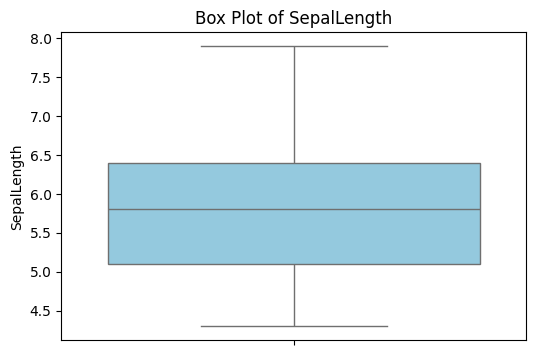

Observation for SepalLength:
Number of outliers = 0
----------------------------------------


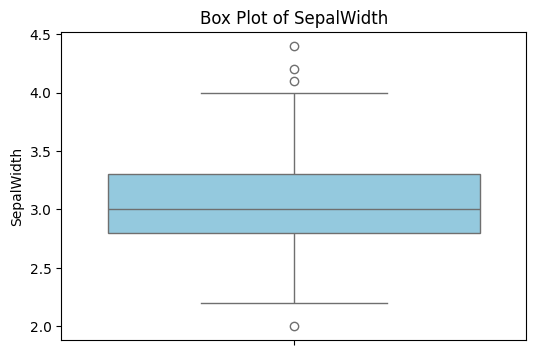

Observation for SepalWidth:
Number of outliers = 4
----------------------------------------


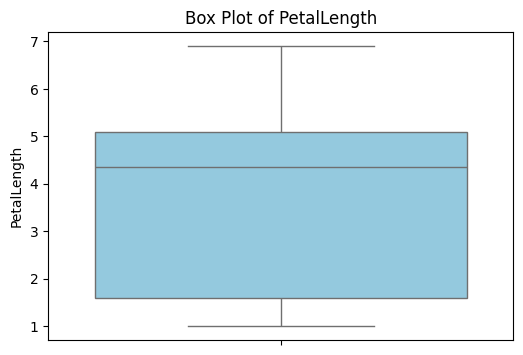

Observation for PetalLength:
Number of outliers = 0
----------------------------------------


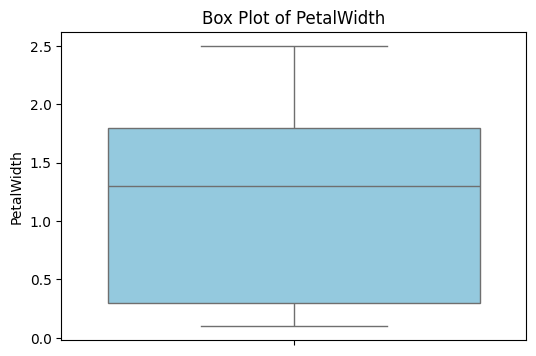

Observation for PetalWidth:
Number of outliers = 0
----------------------------------------


In [ ]:
numeric = df.select_dtypes(include=np.number)

for col in numeric.columns:

    plt.figure(figsize=(6,4))

    sns.boxplot(y=df[col], color='skyblue')

    plt.title(f"Box Plot of {col}")
    plt.ylabel(col)

    plt.show()

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = ((df[col] < (Q1-1.5*IQR)) | (df[col] > (Q3+1.5*IQR))).sum()

    print(f"Observation for {col}:")
    print(f"Number of outliers = {outliers}")
    print("-"*40)

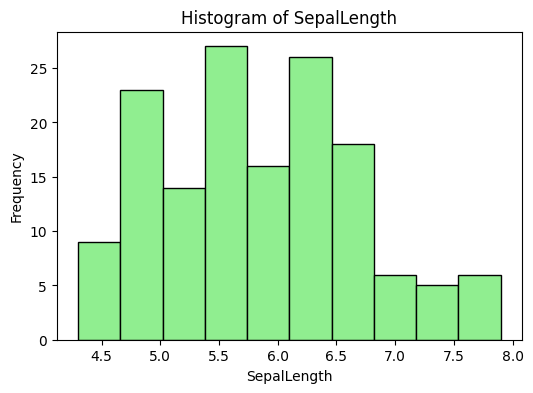

Observation for SepalLength:
Minimum Value = 4.3
Maximum Value = 7.9
Mean Value = 5.84
----------------------------------------


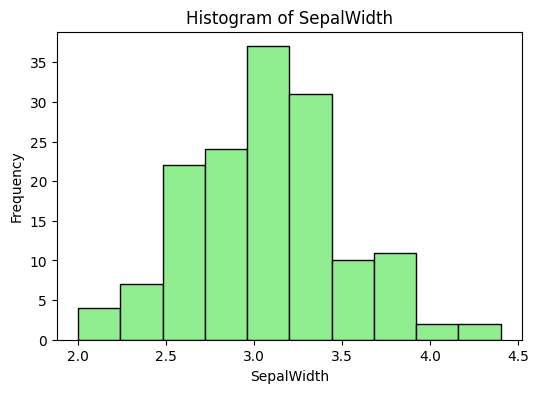

Observation for SepalWidth:
Minimum Value = 2.0
Maximum Value = 4.4
Mean Value = 3.06
----------------------------------------


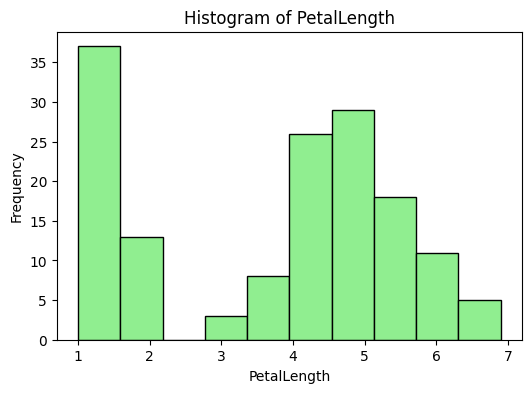

Observation for PetalLength:
Minimum Value = 1.0
Maximum Value = 6.9
Mean Value = 3.76
----------------------------------------


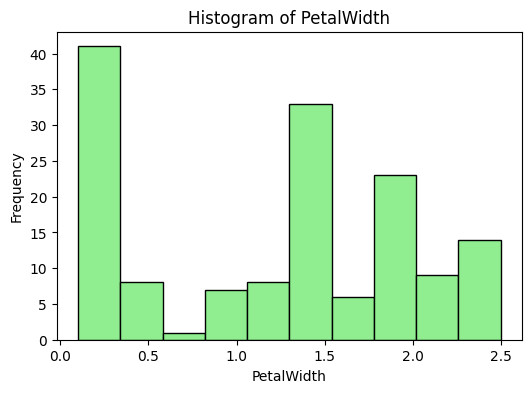

Observation for PetalWidth:
Minimum Value = 0.1
Maximum Value = 2.5
Mean Value = 1.20
----------------------------------------


In [ ]:
numeric = df.select_dtypes(include=np.number)

for col in numeric.columns:

    plt.figure(figsize=(6,4))

    plt.hist(df[col], bins=10, color='lightgreen', edgecolor='black')

    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()

    print(f"Observation for {col}:")
    print(f"Minimum Value = {df[col].min()}")
    print(f"Maximum Value = {df[col].max()}")
    print(f"Mean Value = {df[col].mean():.2f}")
    print("-"*40)

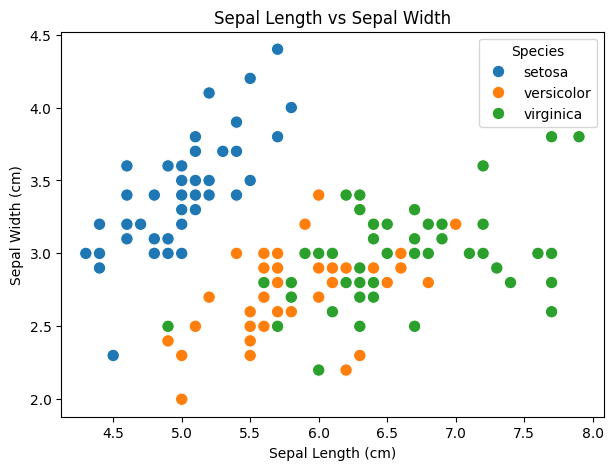

Observation:
Total Species = 3
Correlation = -0.118


In [ ]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="SepalLength",
    y="SepalWidth",
    hue="Species",
    s=80
)

plt.title("Sepal Length vs Sepal Width")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")

plt.show()

print("Observation:")
print(f"Total Species = {df['Species'].nunique()}")
print(f"Correlation = {df['SepalLength'].corr(df['SepalWidth']):.3f}")

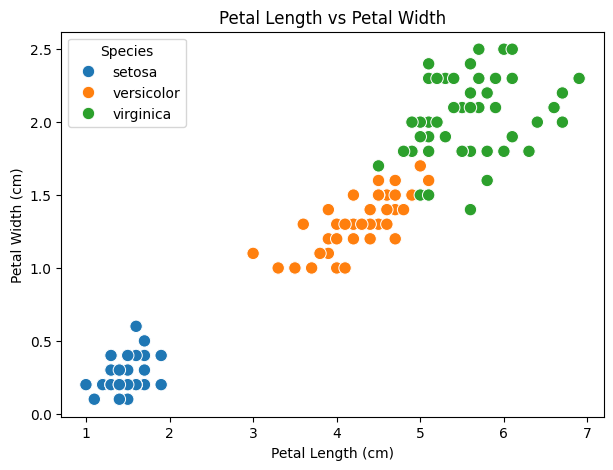

Observation:
Correlation = 0.963


In [ ]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="PetalLength",
    y="PetalWidth",
    hue="Species",
    s=80
)

plt.title("Petal Length vs Petal Width")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")

plt.show()

print("Observation:")
print(f"Correlation = {df['PetalLength'].corr(df['PetalWidth']):.3f}")

In [ ]:
corr = numeric.corr()

print(corr)

print("\nObservation:")

highest = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()

pair = highest.idxmax()

print(f"The strongest positive correlation is between {pair[0]} and {pair[1]}.")

             SepalLength  SepalWidth  PetalLength  PetalWidth
SepalLength     1.000000   -0.117570     0.871754    0.817941
SepalWidth     -0.117570    1.000000    -0.428440   -0.366126
PetalLength     0.871754   -0.428440     1.000000    0.962865
PetalWidth      0.817941   -0.366126     0.962865    1.000000

Observation:
The strongest positive correlation is between PetalLength and PetalWidth.


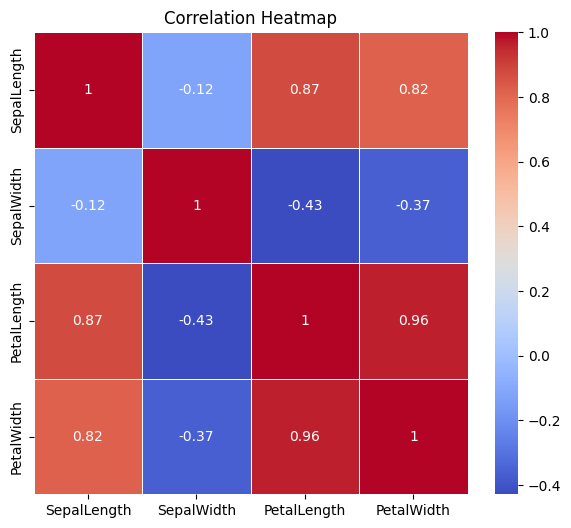

Observation:
The highest correlation is between PetalLength and PetalWidth.


In [ ]:
corr = numeric.corr()

plt.figure(figsize=(7,6))

sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Heatmap")

plt.show()

highest = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()

pair = highest.idxmax()

print("Observation:")
print(f"The highest correlation is between {pair[0]} and {pair[1]}.")

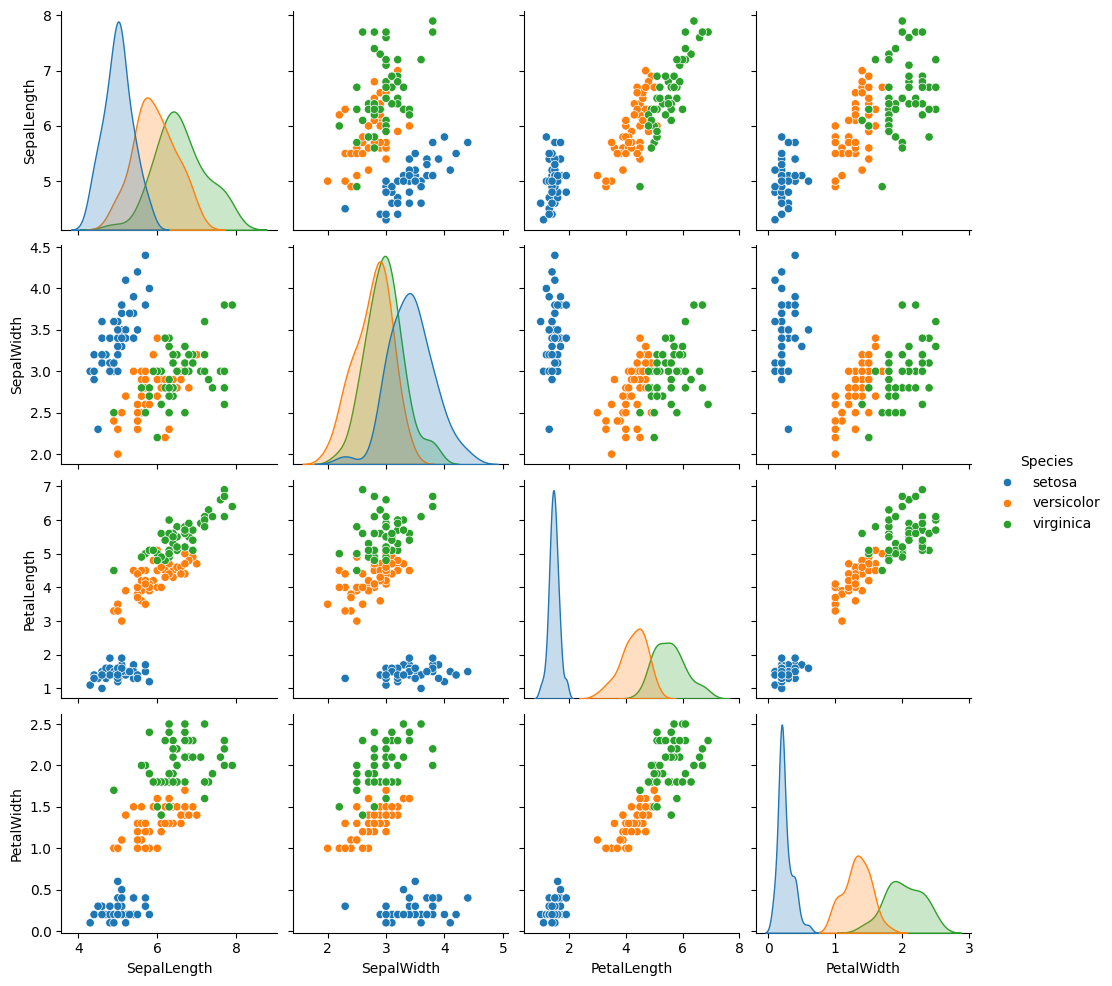

Observation:
The pair plot compares all numerical features for 3 flower species.


In [ ]:
sns.pairplot(df, hue="Species")

plt.show()

print("Observation:")
print(f"The pair plot compares all numerical features for {df['Species'].nunique()} flower species.")

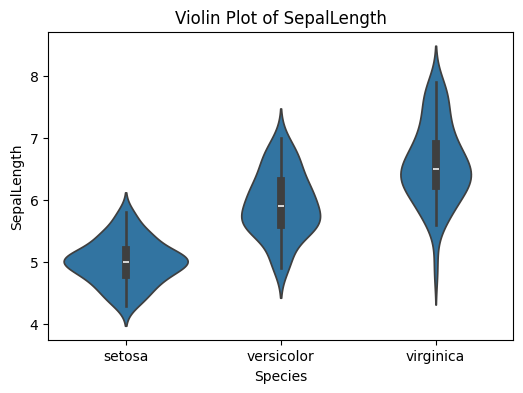

Observation for SepalLength:
Average SepalLength = 5.84
----------------------------------------


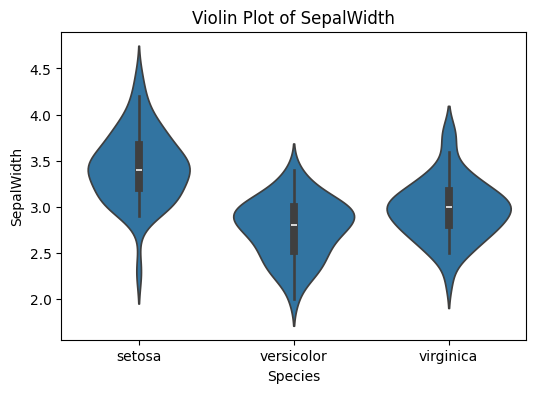

Observation for SepalWidth:
Average SepalWidth = 3.06
----------------------------------------


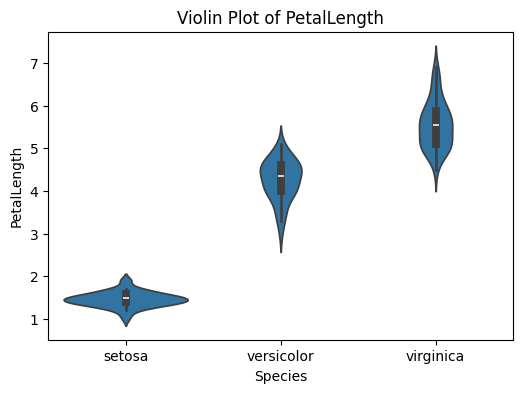

Observation for PetalLength:
Average PetalLength = 3.76
----------------------------------------


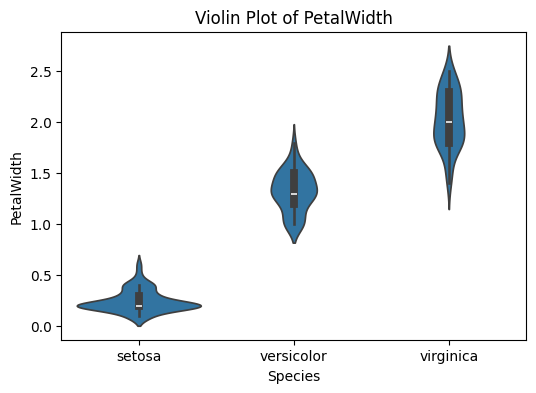

Observation for PetalWidth:
Average PetalWidth = 1.20
----------------------------------------


In [ ]:
for col in numeric.columns:

    plt.figure(figsize=(6,4))

    sns.violinplot(x="Species", y=col, data=df)

    plt.title(f"Violin Plot of {col}")

    plt.xlabel("Species")
    plt.ylabel(col)

    plt.show()

    print(f"Observation for {col}:")
    print(f"Average {col} = {df[col].mean():.2f}")
    print("-"*40)

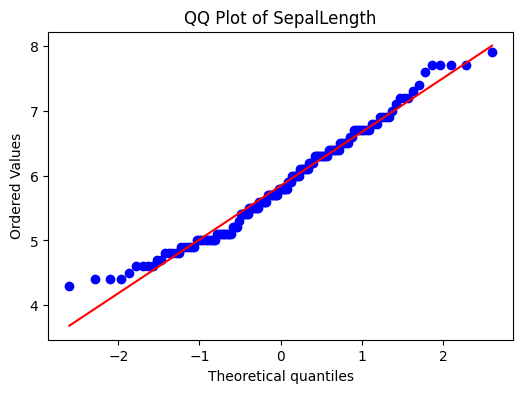

Observation for SepalLength:
The QQ plot compares the feature distribution with a normal distribution.
----------------------------------------


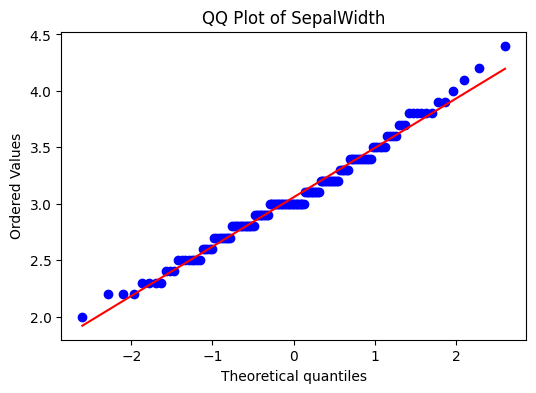

Observation for SepalWidth:
The QQ plot compares the feature distribution with a normal distribution.
----------------------------------------


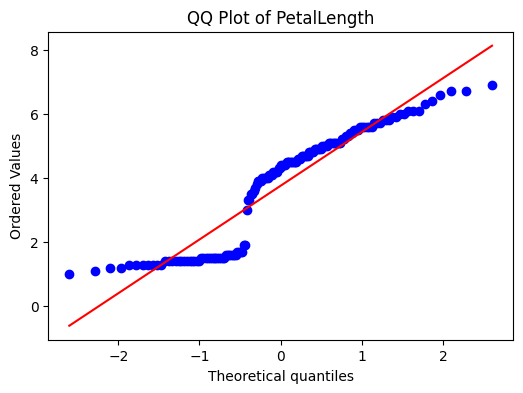

Observation for PetalLength:
The QQ plot compares the feature distribution with a normal distribution.
----------------------------------------


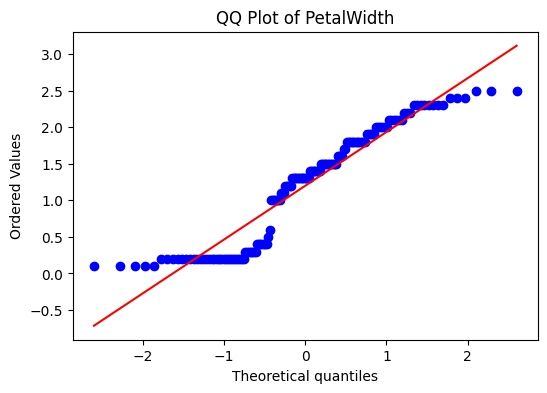

Observation for PetalWidth:
The QQ plot compares the feature distribution with a normal distribution.
----------------------------------------


In [ ]:
for col in numeric.columns:

    plt.figure(figsize=(6,4))

    probplot(df[col], dist="norm", plot=plt)

    plt.title(f"QQ Plot of {col}")

    plt.show()

    print(f"Observation for {col}:")
    print("The QQ plot compares the feature distribution with a normal distribution.")
    print("-"*40)

In [ ]:
species_mean = df.groupby("Species").mean()

display(species_mean)

print("\nObservation:")

for species in species_mean.index:

    highest_feature = species_mean.loc[species].idxmax()

    print(f"{species} has the highest average value in {highest_feature}.")

,SepalLength,SepalWidth,PetalLength,PetalWidth
Species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026



Observation:
setosa has the highest average value in SepalLength.
versicolor has the highest average value in SepalLength.
virginica has the highest average value in SepalLength.


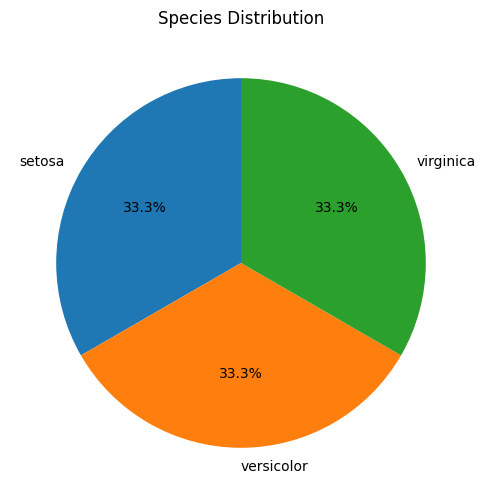

Observation:
All species contribute equally to the dataset.


In [ ]:
species_count = df["Species"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    species_count,
    labels=species_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Species Distribution")

plt.show()

print("Observation:")

if species_count.nunique() == 1:
    print("All species contribute equally to the dataset.")
else:
    print("The dataset is not evenly distributed among the species.")

In [ ]:
print("FINAL CONCLUSION\n")

print(f"Total Samples        : {len(df)}")
print(f"Total Features       : {numeric.shape[1]}")
print(f"Total Species        : {df['Species'].nunique()}")
print(f"Missing Values       : {df.isnull().sum().sum()}")

print("\nFlower Species in the Dataset:")

for flower in df["Species"].unique():
    print("-", flower)

highest_corr = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().idxmax()

print(f"\nHighest Correlation  : {highest_corr[0]} and {highest_corr[1]}")

print("\nObservation:")
print("The Iris dataset consists of three flower species: Iris-setosa, Iris-versicolor, and Iris-virginica.")
print("The dataset contains no missing values and all statistical measures and graphical analyses were successfully performed.")
print(f"The strongest correlation exists between {highest_corr[0]} and {highest_corr[1]}, indicating a strong relationship between these two features.")
print("Hence, the Iris dataset is suitable for statistical analysis and machine learning applications such as classification.")

FINAL CONCLUSION

Total Samples        : 150
Total Features       : 4
Total Species        : 3
Missing Values       : 0

Flower Species in the Dataset:
- setosa
- versicolor
- virginica

Highest Correlation  : PetalLength and PetalWidth

Observation:
The Iris dataset consists of three flower species: Iris-setosa, Iris-versicolor, and Iris-virginica.
The dataset contains no missing values and all statistical measures and graphical analyses were successfully performed.
The strongest correlation exists between PetalLength and PetalWidth, indicating a strong relationship between these two features.
Hence, the Iris dataset is suitable for statistical analysis and machine learning applications such as classification.
